# AB 2GPU ?? ???
`train_resnet_ab_2gpu_ddp.py`? ?? ??????? ???? ?? ??? ??? ????? ?? ??????.

- 1?: `seed=42`? ?? coarse search
- 2?: ?? ??? `seed=[42,7,123]`? ???
- ???: ?? ?? `.pth` ?? + ?? ?/???


In [1]:
import json
import subprocess
from pathlib import Path
from itertools import product
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path(r"c:\Users\ldy34\Desktop\Face")
ML = BASE / "ML"
VENV_PY = BASE / ".venv" / "Scripts" / "python.exe"
TRAIN_PY = ML / "train_resnet_ab_2gpu_ddp.py"

OUT_ROOT = ML / "experiments_ab_2gpu_tuning"
OUT_ROOT.mkdir(exist_ok=True)

print("Python:", VENV_PY)
print("Trainer exists:", TRAIN_PY.exists())
print("Out root:", OUT_ROOT)


Python: c:\Users\ldy34\Desktop\Face\.venv\Scripts\python.exe
Trainer exists: True
Out root: c:\Users\ldy34\Desktop\Face\ML\experiments_ab_2gpu_tuning


In [2]:
BASE_CFG = {
    "base_dir": str(BASE / "video"),
    "cache_path": str(ML / "cache_landmarks_7class.npz"),
    "force_rebuild_cache": False,

    "num_gpus": 2,
    "batch_size_per_gpu": 256,
    "extract_workers": 12,
    "loader_workers": 4,
    "max_per_zip": 5000,

    "test_size": 0.15,
    "val_size": 0.15,

    "epochs_binary_direct": 140,
    "epochs_pretrain7": 160,
    "epochs_binary_finetune": 100,

    "lr_binary_direct": 2e-4,
    "lr_pretrain7": 8e-4,
    "lr_binary_finetune": 3e-4,

    "weight_decay": 1e-4,
    "hidden_dim": 512,
    "dropout_block": 0.3,
    "dropout_head": 0.2,

    "label_smoothing": 0.01,
    "noise_std": 0.0005,

    "early_stop_patience": 35,
    "early_stop_min_delta": 1e-4,
    "amp": True,
}

TARGET_TEST_ACC = 0.852
SEEDS_COARSE = [42]
SEEDS_FULL = [42, 7, 123]
TOPK_FOR_FULL = 3

BASE_CFG


{'base_dir': 'c:\\Users\\ldy34\\Desktop\\Face\\video',
 'cache_path': 'c:\\Users\\ldy34\\Desktop\\Face\\ML\\cache_landmarks_7class.npz',
 'force_rebuild_cache': False,
 'num_gpus': 2,
 'batch_size_per_gpu': 256,
 'extract_workers': 12,
 'loader_workers': 4,
 'max_per_zip': 5000,
 'test_size': 0.15,
 'val_size': 0.15,
 'epochs_binary_direct': 140,
 'epochs_pretrain7': 160,
 'epochs_binary_finetune': 100,
 'lr_binary_direct': 0.0002,
 'lr_pretrain7': 0.0008,
 'lr_binary_finetune': 0.0003,
 'weight_decay': 0.0001,
 'hidden_dim': 512,
 'dropout_block': 0.3,
 'dropout_head': 0.2,
 'label_smoothing': 0.01,
 'noise_std': 0.0005,
 'early_stop_patience': 35,
 'early_stop_min_delta': 0.0001,
 'amp': True}

In [3]:
# ?? ???(?? ??? ??? ???? ?? 6~8?? ??)
EXPERIMENTS = [
    {
        "name": "tune_a_stable",
        "overrides": {
            "lr_binary_direct": 2e-4,
            "noise_std": 0.0005,
            "label_smoothing": 0.01,
            "dropout_head": 0.25,
        },
    },
    {
        "name": "tune_b_low_lr",
        "overrides": {
            "lr_binary_direct": 1e-4,
            "noise_std": 0.0005,
            "label_smoothing": 0.01,
        },
    },
    {
        "name": "tune_c_no_noise",
        "overrides": {
            "lr_binary_direct": 2e-4,
            "noise_std": 0.0,
            "label_smoothing": 0.01,
        },
    },
    {
        "name": "tune_d_soft_reg",
        "overrides": {
            "lr_binary_direct": 3e-4,
            "noise_std": 0.0005,
            "label_smoothing": 0.0,
            "dropout_head": 0.2,
        },
    },
    {
        "name": "tune_e_pretrain_focus",
        "overrides": {
            "lr_pretrain7": 6e-4,
            "lr_binary_finetune": 2e-4,
            "epochs_pretrain7": 180,
            "epochs_binary_finetune": 120,
            "noise_std": 0.0005,
            "label_smoothing": 0.01,
        },
    },
    {
        "name": "tune_f_small_model",
        "overrides": {
            "hidden_dim": 384,
            "dropout_head": 0.3,
            "lr_binary_direct": 2e-4,
            "noise_std": 0.0005,
            "label_smoothing": 0.01,
        },
    },
]

pd.DataFrame([{"name": e["name"], **e["overrides"]} for e in EXPERIMENTS])


,name,lr_binary_direct,noise_std,label_smoothing,dropout_head,lr_pretrain7,lr_binary_finetune,epochs_pretrain7,epochs_binary_finetune,hidden_dim
0,tune_a_stable,0.0002,0.0005,0.01,0.25,NaN,NaN,NaN,NaN,NaN
1,tune_b_low_lr,0.0001,0.0005,0.01,NaN,NaN,NaN,NaN,NaN,NaN
2,tune_c_no_noise,0.0002,0.0000,0.01,NaN,NaN,NaN,NaN,NaN,NaN
3,tune_d_soft_reg,0.0003,0.0005,0.00,0.20,NaN,NaN,NaN,NaN,NaN
4,tune_e_pretrain_focus,NaN,0.0005,0.01,NaN,0.0006,0.0002,180.0,120.0,NaN
5,tune_f_small_model,0.0002,0.0005,0.01,0.30,NaN,NaN,NaN,NaN,384.0


In [4]:
def build_cmd(cfg: dict, seed: int, out_dir: Path):
    cmd = [
        str(VENV_PY),
        str(TRAIN_PY),
        "--base-dir", cfg["base_dir"],
        "--out-dir", str(out_dir),
        "--cache-path", cfg["cache_path"],

        "--num-gpus", str(cfg["num_gpus"]),
        "--batch-size-per-gpu", str(cfg["batch_size_per_gpu"]),
        "--extract-workers", str(cfg["extract_workers"]),
        "--loader-workers", str(cfg["loader_workers"]),
        "--max-per-zip", str(cfg["max_per_zip"]),

        "--seed", str(seed),
        "--test-size", str(cfg["test_size"]),
        "--val-size", str(cfg["val_size"]),

        "--epochs-binary-direct", str(cfg["epochs_binary_direct"]),
        "--epochs-pretrain7", str(cfg["epochs_pretrain7"]),
        "--epochs-binary-finetune", str(cfg["epochs_binary_finetune"]),

        "--lr-binary-direct", str(cfg["lr_binary_direct"]),
        "--lr-pretrain7", str(cfg["lr_pretrain7"]),
        "--lr-binary-finetune", str(cfg["lr_binary_finetune"]),

        "--weight-decay", str(cfg["weight_decay"]),
        "--hidden-dim", str(cfg["hidden_dim"]),
        "--dropout-block", str(cfg["dropout_block"]),
        "--dropout-head", str(cfg["dropout_head"]),

        "--label-smoothing", str(cfg["label_smoothing"]),
        "--noise-std", str(cfg["noise_std"]),

        "--early-stop-patience", str(cfg["early_stop_patience"]),
        "--early-stop-min-delta", str(cfg["early_stop_min_delta"]),
    ]
    if cfg["force_rebuild_cache"]:
        cmd.append("--force-rebuild-cache")
    cmd.append("--amp" if cfg["amp"] else "--no-amp")
    return cmd


def run_one_seed(cfg: dict, seed: int, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    summary_path = out_dir / "ab_summary.json"
    if summary_path.exists():
        print(f"SKIP completed: {out_dir}")
        return True

    # Windows ???: worker fallback
    candidates = [cfg["loader_workers"], 2, 0]
    candidates = list(dict.fromkeys(candidates))

    for lw in candidates:
        trial_cfg = dict(cfg)
        trial_cfg["loader_workers"] = lw
        cmd = build_cmd(trial_cfg, seed, out_dir)

        print("\n" + "=" * 90)
        print(f"RUN seed={seed} | out={out_dir.name} | loader_workers={lw}")
        print("CMD:", " ".join(cmd))

        try:
            subprocess.run(cmd, cwd=str(BASE), check=True)
            return True
        except subprocess.CalledProcessError:
            print(f"[WARN] failed with loader_workers={lw}, fallback...")

    return False


def collect_seed_result(exp_name: str, seed: int, out_dir: Path):
    summary_path = out_dir / "ab_summary.json"
    if not summary_path.exists():
        return None

    with open(summary_path, "r", encoding="utf-8") as f:
        s = json.load(f)

    d = s["results"]["direct_binary"]
    ft = s["results"]["finetune_binary_from7"]

    hist_ft = out_dir / "finetune_binary_best_history.json"
    with open(hist_ft, "r", encoding="utf-8") as f:
        h = json.load(f)

    return {
        "exp": exp_name,
        "seed": seed,
        "direct_test_acc": d["accuracy"],
        "ft_test_acc": ft["accuracy"],
        "ft_test_macro_f1": ft["macro_f1"],
        "ft_best_val_acc": max(h.get("val_acc", [0.0])),
        "delta_ft_minus_direct": ft["accuracy"] - d["accuracy"],
        "model_direct": str(out_dir / "direct_binary_best.pth"),
        "model_ft": str(out_dir / "finetune_binary_best.pth"),
        "out_dir": str(out_dir),
    }


In [5]:
# 1? coarse search (seed=42)
coarse_rows = []
for exp in EXPERIMENTS:
    exp_name = exp["name"]
    cfg = dict(BASE_CFG)
    cfg.update(exp["overrides"])

    for seed in SEEDS_COARSE:
        out_dir = OUT_ROOT / exp_name / f"seed_{seed}"
        ok = run_one_seed(cfg, seed, out_dir)
        if ok:
            rec = collect_seed_result(exp_name, seed, out_dir)
            if rec:
                coarse_rows.append(rec)

coarse_df = pd.DataFrame(coarse_rows).sort_values(["ft_test_acc", "direct_test_acc"], ascending=False)
display(coarse_df)
coarse_df.to_csv(OUT_ROOT / "coarse_results.csv", index=False, encoding="utf-8-sig")
print("saved:", OUT_ROOT / "coarse_results.csv")



RUN seed=42 | out=seed_42 | loader_workers=4
CMD: c:\Users\ldy34\Desktop\Face\.venv\Scripts\python.exe c:\Users\ldy34\Desktop\Face\ML\train_resnet_ab_2gpu_ddp.py --base-dir c:\Users\ldy34\Desktop\Face\video --out-dir c:\Users\ldy34\Desktop\Face\ML\experiments_ab_2gpu_tuning\tune_a_stable\seed_42 --cache-path c:\Users\ldy34\Desktop\Face\ML\cache_landmarks_7class.npz --num-gpus 2 --batch-size-per-gpu 256 --extract-workers 12 --loader-workers 4 --max-per-zip 5000 --seed 42 --test-size 0.15 --val-size 0.15 --epochs-binary-direct 140 --epochs-pretrain7 160 --epochs-binary-finetune 100 --lr-binary-direct 0.0002 --lr-pretrain7 0.0008 --lr-binary-finetune 0.0003 --weight-decay 0.0001 --hidden-dim 512 --dropout-block 0.3 --dropout-head 0.25 --label-smoothing 0.01 --noise-std 0.0005 --early-stop-patience 35 --early-stop-min-delta 0.0001 --amp

RUN seed=42 | out=seed_42 | loader_workers=4
CMD: c:\Users\ldy34\Desktop\Face\.venv\Scripts\python.exe c:\Users\ldy34\Desktop\Face\ML\train_resnet_ab_2gp

,exp,seed,direct_test_acc,ft_test_acc,ft_test_macro_f1,ft_best_val_acc,delta_ft_minus_direct,model_direct,model_ft,out_dir
5,tune_f_small_model,42,0.828918,0.840173,0.840171,0.910185,0.011255,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...
1,tune_b_low_lr,42,0.834459,0.832208,0.832196,0.873686,-0.002251,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...
0,tune_a_stable,42,0.820952,0.830823,0.830795,0.868144,0.009870,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...
3,tune_d_soft_reg,42,0.824416,0.830130,0.830129,0.910568,0.005714,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...
4,tune_e_pretrain_focus,42,0.801558,0.820433,0.820312,0.876744,0.018874,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...
2,tune_c_no_noise,42,0.790476,0.820433,0.820431,0.888209,0.029957,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...


saved: c:\Users\ldy34\Desktop\Face\ML\experiments_ab_2gpu_tuning\coarse_results.csv


In [6]:
# 2? full eval: coarse ?? TOPK? seed 3? ???
if len(coarse_df) == 0:
    raise RuntimeError("No coarse results. Run previous cell first.")

top_exp_names = coarse_df["exp"].drop_duplicates().head(TOPK_FOR_FULL).tolist()
print("Top experiments for full eval:", top_exp_names)

full_rows = []
for exp in EXPERIMENTS:
    if exp["name"] not in top_exp_names:
        continue

    exp_name = exp["name"]
    cfg = dict(BASE_CFG)
    cfg.update(exp["overrides"])

    for seed in SEEDS_FULL:
        out_dir = OUT_ROOT / exp_name / f"seed_{seed}"
        ok = run_one_seed(cfg, seed, out_dir)
        if ok:
            rec = collect_seed_result(exp_name, seed, out_dir)
            if rec:
                full_rows.append(rec)

full_df = pd.DataFrame(full_rows).sort_values(["exp", "seed"])
display(full_df)
full_df.to_csv(OUT_ROOT / "full_results.csv", index=False, encoding="utf-8-sig")
print("saved:", OUT_ROOT / "full_results.csv")


Top experiments for full eval: ['tune_f_small_model', 'tune_b_low_lr', 'tune_a_stable']
SKIP completed: c:\Users\ldy34\Desktop\Face\ML\experiments_ab_2gpu_tuning\tune_a_stable\seed_42

RUN seed=7 | out=seed_7 | loader_workers=4
CMD: c:\Users\ldy34\Desktop\Face\.venv\Scripts\python.exe c:\Users\ldy34\Desktop\Face\ML\train_resnet_ab_2gpu_ddp.py --base-dir c:\Users\ldy34\Desktop\Face\video --out-dir c:\Users\ldy34\Desktop\Face\ML\experiments_ab_2gpu_tuning\tune_a_stable\seed_7 --cache-path c:\Users\ldy34\Desktop\Face\ML\cache_landmarks_7class.npz --num-gpus 2 --batch-size-per-gpu 256 --extract-workers 12 --loader-workers 4 --max-per-zip 5000 --seed 7 --test-size 0.15 --val-size 0.15 --epochs-binary-direct 140 --epochs-pretrain7 160 --epochs-binary-finetune 100 --lr-binary-direct 0.0002 --lr-pretrain7 0.0008 --lr-binary-finetune 0.0003 --weight-decay 0.0001 --hidden-dim 512 --dropout-block 0.3 --dropout-head 0.25 --label-smoothing 0.01 --noise-std 0.0005 --early-stop-patience 35 --early-st

,exp,seed,direct_test_acc,ft_test_acc,ft_test_macro_f1,ft_best_val_acc,delta_ft_minus_direct,model_direct,model_ft,out_dir
1,tune_a_stable,7,0.820936,0.825218,0.825112,0.870381,0.004282,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...
0,tune_a_stable,42,0.820952,0.830823,0.830795,0.868144,0.009870,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...
2,tune_a_stable,123,0.841904,0.840905,0.840820,0.911405,-0.000999,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...
4,tune_b_low_lr,7,0.821412,0.825852,0.825799,0.893548,0.004441,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...
3,tune_b_low_lr,42,0.834459,0.832208,0.832196,0.873686,-0.002251,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...
5,tune_b_low_lr,123,0.830587,0.838908,0.838866,0.909369,0.008321,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...
7,tune_f_small_model,7,0.824266,0.840285,0.840283,0.911545,0.016019,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...
6,tune_f_small_model,42,0.828918,0.840173,0.840171,0.910185,0.011255,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...
8,tune_f_small_model,123,0.853054,0.842403,0.842393,0.901833,-0.010651,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...,c:\Users\ldy34\Desktop\Face\ML\experiments_ab_...


saved: c:\Users\ldy34\Desktop\Face\ML\experiments_ab_2gpu_tuning\full_results.csv


In [7]:
# ??? ??/???? ?? + ?? ??? ??
if len(full_df) == 0:
    raise RuntimeError("No full results. Run previous cell first.")

agg = (
    full_df.groupby("exp", as_index=False)
    .agg(
        direct_test_acc_mean=("direct_test_acc", "mean"),
        direct_test_acc_std=("direct_test_acc", "std"),
        ft_test_acc_mean=("ft_test_acc", "mean"),
        ft_test_acc_std=("ft_test_acc", "std"),
        ft_macro_f1_mean=("ft_test_macro_f1", "mean"),
        ft_best_val_acc_mean=("ft_best_val_acc", "mean"),
    )
    .sort_values(["ft_test_acc_mean", "direct_test_acc_mean"], ascending=False)
)

display(agg)
agg.to_csv(OUT_ROOT / "aggregate_results.csv", index=False, encoding="utf-8-sig")

best_exp = agg.iloc[0]["exp"]
best_rows = full_df[full_df["exp"] == best_exp].sort_values(["ft_test_acc", "direct_test_acc"], ascending=False)
best_seed_row = best_rows.iloc[0]

print("\nBest experiment:", best_exp)
print("Best seed row:")
print(best_seed_row[["seed", "direct_test_acc", "ft_test_acc", "ft_test_macro_f1", "ft_best_val_acc"]])
print("\nRecommended binary deployment candidates:")
print("  direct:", best_seed_row["model_direct"])
print("  finetune:", best_seed_row["model_ft"])

best_acc = max(float(best_seed_row["direct_test_acc"]), float(best_seed_row["ft_test_acc"]))
print("\nTarget test acc", TARGET_TEST_ACC, "| exceeded:", best_acc >= TARGET_TEST_ACC)


,exp,direct_test_acc_mean,direct_test_acc_std,ft_test_acc_mean,ft_test_acc_std,ft_macro_f1_mean,ft_best_val_acc_mean
2,tune_f_small_model,0.835413,0.015454,0.840954,0.001256,0.840949,0.907854
1,tune_b_low_lr,0.828819,0.006701,0.832323,0.006529,0.832287,0.892201
0,tune_a_stable,0.827931,0.012101,0.832315,0.007949,0.832242,0.883310



Best experiment: tune_f_small_model
Best seed row:
seed                     123
direct_test_acc     0.853054
ft_test_acc         0.842403
ft_test_macro_f1    0.842393
ft_best_val_acc     0.901833
Name: 8, dtype: object

Recommended binary deployment candidates:
  direct: c:\Users\ldy34\Desktop\Face\ML\experiments_ab_2gpu_tuning\tune_f_small_model\seed_123\direct_binary_best.pth
  finetune: c:\Users\ldy34\Desktop\Face\ML\experiments_ab_2gpu_tuning\tune_f_small_model\seed_123\finetune_binary_best.pth

Target test acc 0.852 | exceeded: True


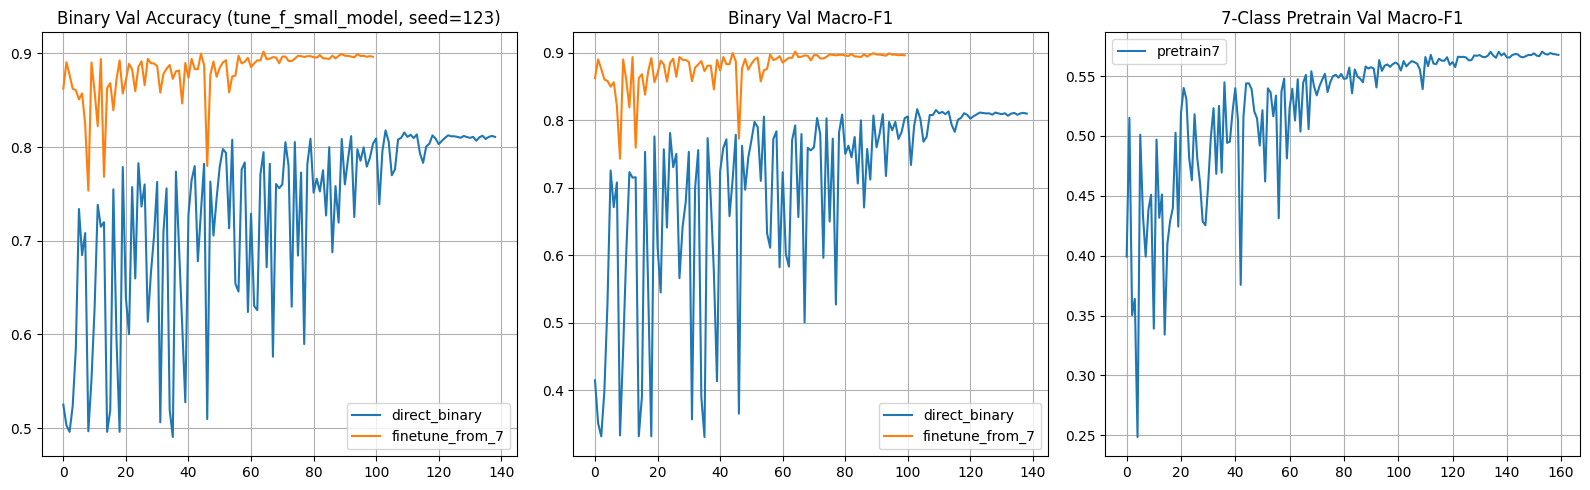

In [8]:
# ??? ??? ?? ?? ???
best_out_dir = Path(best_seed_row["out_dir"])

def load_hist(name):
    with open(best_out_dir / name, "r", encoding="utf-8") as f:
        return json.load(f)

h_direct = load_hist("direct_binary_best_history.json")
h_pre7 = load_hist("pretrain7_best_history.json")
h_ft = load_hist("finetune_binary_best_history.json")

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.plot(h_direct["val_acc"], label="direct_binary")
plt.plot(h_ft["val_acc"], label="finetune_from_7")
plt.title(f"Binary Val Accuracy ({best_exp}, seed={int(best_seed_row['seed'])})")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(h_direct["val_macro_f1"], label="direct_binary")
plt.plot(h_ft["val_macro_f1"], label="finetune_from_7")
plt.title("Binary Val Macro-F1")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(h_pre7["val_macro_f1"], label="pretrain7")
plt.title("7-Class Pretrain Val Macro-F1")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
